# Import Needed Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt


# !pip install termcolor
import colorama
from colorama import Fore, Style  # makes strings colored
from termcolor import colored
from termcolor import cprint


import warnings
warnings.filterwarnings('ignore')

# User Defined Functions

In [4]:
def first_looking(df):
    print(colored("Shape:", attrs=['bold']), df.shape,'\n', 
          colored('*'*100, 'blue', attrs=['bold']),
          colored("\nInfo:\n", attrs=['bold']), sep='')
    print(df.info(), '\n', 
          colored('*'*100, 'blue', attrs=['bold']), sep='')
    print(colored("Number of Uniques:\n", attrs=['bold']), df.nunique(),'\n',
          colored('*'*100, 'blue', attrs=['bold']), sep='')
    print(colored("Missing Values:\n", attrs=['bold']), missing_values(df),'\n', 
          colored('*'*100, 'blue', attrs=['bold']), sep='')
    print(colored("All Columns:", attrs=['bold']), list(df.columns),'\n', 
          colored('*'*100, 'blue', attrs=['bold']), sep='')

###############################################################

def feature_looking(df, col):
    print("column name    : ", col)  # Prints out related column name
    print("--------------------------------")
    print("per_of_nulls   : ", "%", round(df[col].isnull().sum() * 100 / df.shape[0], 2))  # Calculates the percentage of Null values for related column
    print("num_of_nulls   : ", df[col].isnull().sum())  # Prints out the total number of Null values for related column
    print("num_of_uniques : ", df[col].astype(str).nunique())  # Prints out the number of unique values for related column
    print("shape_of_df    : ", df.shape)  # Prints out the shape of DataFrame
    print("--------------------------------")
    print(df[col].value_counts(dropna=False))  # Prints out the number of occurance for unique values in the related column
    
###############################################################

def missing_values(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return missing_values[missing_values['Missing_Number']>0]

###############################################################

def duplicate_values(df):
    print(colored("Duplicate check...", attrs=['bold']), sep='')
    duplicate_values = df.duplicated(subset=None, keep='first').sum()
    if duplicate_values > 0:
        df.drop_duplicates(keep='first', inplace=True)
        print(duplicate_values, colored(" Duplicates were dropped!"),'\n',
              colored('*'*100, 'blue', attrs=['bold']), sep='')
    else:
        print(colored("There are no duplicates"),'\n',
              colored('*'*100, 'blue', attrs=['bold']), sep='') 

###############################################################

# State identification function by ZIP codes
def get_state(zip_code):
    if 35000 <= zip_code <= 36999: return "Alabama"
    elif 99500 <= zip_code <= 99999: return "Alaska"
    elif 85000 <= zip_code <= 86999: return "Arizona"
    elif 71600 <= zip_code <= 72999: return "Arkansas"
    elif 90000 <= zip_code <= 96199: return "California"
    elif 80000 <= zip_code <= 81999: return "Colorado"
    elif 6000 <= zip_code <= 6999: return "Connecticut"
    elif 19700 <= zip_code <= 19999: return "Delaware"
    elif 32000 <= zip_code <= 34999: return "Florida"
    elif 30000 <= zip_code <= 31999: return "Georgia"
    elif 96700 <= zip_code <= 96999: return "Hawaii"
    elif 83200 <= zip_code <= 83999: return "Idaho"
    elif 60000 <= zip_code <= 62999: return "Illinois"
    elif 46000 <= zip_code <= 47999: return "Indiana"
    elif 50000 <= zip_code <= 52999: return "Iowa"
    elif 66000 <= zip_code <= 67999: return "Kansas"
    elif 40000 <= zip_code <= 42999: return "Kentucky"
    elif 70000 <= zip_code <= 71599: return "Louisiana"
    elif 3900 <= zip_code <= 4999: return "Maine"
    elif 20600 <= zip_code <= 21999: return "Maryland"
    elif 1000 <= zip_code <= 2799: return "Massachusetts"
    elif 48000 <= zip_code <= 49999: return "Michigan"
    elif 55000 <= zip_code <= 56999: return "Minnesota"
    elif 38600 <= zip_code <= 39999: return "Mississippi"
    elif 63000 <= zip_code <= 65999: return "Missouri"
    elif 59000 <= zip_code <= 59999: return "Montana"
    elif 68000 <= zip_code <= 69999: return "Nebraska"
    elif 88900 <= zip_code <= 89999: return "Nevada"
    elif 3000 <= zip_code <= 3899: return "New Hampshire"
    elif 7000 <= zip_code <= 8999: return "New Jersey"
    elif 87000 <= zip_code <= 88499: return "New Mexico"
    elif 10000 <= zip_code <= 14999: return "New York"
    elif 27000 <= zip_code <= 28999: return "North Carolina"
    elif 58000 <= zip_code <= 58999: return "North Dakota"
    elif 43000 <= zip_code <= 45999: return "Ohio"
    elif 73000 <= zip_code <= 74999: return "Oklahoma"
    elif 97000 <= zip_code <= 97999: return "Oregon"
    elif 15000 <= zip_code <= 19699: return "Pennsylvania"
    elif 300 <= zip_code <= 999: return "Puerto Rico"
    elif 2800 <= zip_code <= 2999: return "Rhode Island"
    elif 29000 <= zip_code <= 29999: return "South Carolina"
    elif 57000 <= zip_code <= 57999: return "South Dakota"
    elif 37000 <= zip_code <= 38599: return "Tennessee"
    elif 75000 <= zip_code <= 79999: return "Texas"
    elif 84000 <= zip_code <= 84999: return "Utah"
    elif 5000 <= zip_code <= 5999: return "Vermont"
    elif 22000 <= zip_code <= 24699: return "Virginia"
    elif 20000 <= zip_code <= 20599: return "Washington, D.C."
    elif 98000 <= zip_code <= 99499: return "Washington"
    elif 24700 <= zip_code <= 26999: return "West Virginia"
    elif 53000 <= zip_code <= 54999: return "Wisconsin"
    elif 82000 <= zip_code <= 83199: return "Wyoming"
    else: return "Unknown"

# Loading Dataset

In [6]:
#import pandas as pd
#import glob
#
#folder_path = "C:/Users/Ahmet/Desktop/Trainee/data"
#excel_files = glob.glob(f"{folder_path}/*.xlsx")  # Get all Excel files
#
#dataframes = {}  # Dictionary to store DataFrames separately
#
#for file in excel_files:
#    file_name = file.split("/")[-1]  # Extract file name
#    df = pd.read_excel(file)  # Load Excel file into DataFrame
#    dataframes[file_name] = df  # Store DataFrame with file name as key
#
## Print DataFrames loaded separately
#for name, df in dataframes.items():
#    print(f"Data from {name}:")
#    print(df.head(), "\n")


In [7]:
folder_path = "C:/Users/Ahmet/Desktop/Trainee/data"
file_name = "coffee_survey_sallys_brew_2024.xlsx" 

file_path = os.path.join(folder_path, file_name)

df = pd.read_excel(file_path)

df.head()

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,Column 0,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,...,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts,Column1
0,3956,BG0pZK,25-34 years old,1,At home,NaN,NaN,Pour over,Espresso Machine,Local,...,White/Caucasian,NaN,Employed full-time,1,No affiliation,True,Subscription - Light,11215,Yes,NaN
1,3325,GrY6JZ,25-34 years old,3,At home,NaN,NaN,Pour over,Kettle,Independent,...,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Nordic,11215,NaN,NaN
2,3646,VZovVj,25-34 years old,Less than 1,At home,NaN,NaN,Other,Coffee Grinder,Specialty,...,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11215,Yes,NaN
3,1170,DVv685,25-34 years old,2,At home,NaN,NaN,French press,Coffee Grinder,Local,...,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11215,No,NaN
4,3978,9d4vR4,25-34 years old,2,NaN,NaN,NaN,Pour over,Espresso Machine,Specialty,...,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11215,No,NaN


In [8]:
duplicate_values(df)

Duplicate check...
There are no duplicates
****************************************************************************************************


In [9]:
df0 = df.copy()
df0.head(2)

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,Column 0,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,...,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts,Column1
0,3956,BG0pZK,25-34 years old,1,At home,NaN,NaN,Pour over,Espresso Machine,Local,...,White/Caucasian,NaN,Employed full-time,1,No affiliation,True,Subscription - Light,11215,Yes,NaN
1,3325,GrY6JZ,25-34 years old,3,At home,NaN,NaN,Pour over,Kettle,Independent,...,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Nordic,11215,NaN,NaN


# First Look at the Data

In [11]:
first_looking(df)

Shape:(4062, 55)
****************************************************************************************************
Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4062 entries, 0 to 4061
Data columns (total 55 columns):
 #   Column                                                                                            Non-Null Count  Dtype  
---  ------                                                                                            --------------  -----  
 0   F1                                                                                                4062 non-null   int64  
 1   Submission ID                                                                                     4062 non-null   object 
 2   What is your age?                                                                                 4031 non-null   object 
 3   How many cups of coffee do you typically drink per day?                                           3969 non-null   object 
 4   W

In [12]:
missing_values(df)

,Missing_Number,Missing_Percent
Column1,4062,100.000000
Column 0,4062,100.000000
What other flavoring do you use?,4062,100.000000
What kind of flavorings do you add?1,4062,100.000000
Gender (please specify),4050,99.704579
What else do you add to your coffee?,4013,98.793698
Ethnicity/Race (please specify),3956,97.390448
Please specify what your favorite coffee drink is,3948,97.193501
Other reason for drinking coffee,3894,95.864106
Where else do you purchase coffee?,3638,89.561792


In [13]:
df = df.dropna(axis=1, how='all')
# Dropped which columns have %100 missing value rate.

In [14]:
df.drop(columns=['F1', 'Submission ID']).isna().all(axis=1).sum()
# Checked if there are any rows where all values are null

0

# Feature Analysing

## 'F1'

In [17]:
feature_looking(df,'F1')

column name    :  F1
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  4062
shape_of_df    :  (4062, 51)
--------------------------------
F1
3956    1
2269    1
134     1
3587    1
3851    1
       ..
2453    1
1938    1
2855    1
617     1
1998    1
Name: count, Length: 4062, dtype: int64


* Unique value for each row like index number

## 'Submission ID'

In [20]:
feature_looking(df,'Submission ID')

column name    :  Submission ID
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  4042
shape_of_df    :  (4062, 51)
--------------------------------
Submission ID
pL54N8    2
dYzkGz    2
QAjOAg    2
ZdWzBV    2
Rz2JQv    2
         ..
8dp7Zk    1
EPboA4    1
yl0p26    1
RzZQG9    1
KMBEEg    1
Name: count, Length: 4042, dtype: int64


In [21]:
df[df['Submission ID']=='pL54N8'].T

,890,891
F1,4034,4054
Submission ID,pL54N8,pL54N8
What is your age?,18-24 years old,18-24 years old
How many cups of coffee do you typically drink per day?,Less than 1,Less than 1
Where do you typically drink coffee? Choice_nr_1,At home,At home
Where do you typically drink coffee? Choice_nr_2,"At the office, At a cafe","At the office, At a cafe"
How do you brew coffee at home?1,Pour over,Pour over
coffee_accessories,Milk Frother,Milk Frother
coffee_shop_preference,Local,Local
"On the go, where do you typically purchase coffee?1",NaN,NaN


In [22]:
df[df['Submission ID']=='dYzkGz'].T

,779,780
F1,4027,4047
Submission ID,dYzkGz,dYzkGz
What is your age?,25-34 years old,25-34 years old
How many cups of coffee do you typically drink per day?,1,1
Where do you typically drink coffee? Choice_nr_1,At home,At home
Where do you typically drink coffee? Choice_nr_2,NaN,NaN
How do you brew coffee at home?1,Espresso,Espresso
coffee_accessories,Kettle,Kettle
coffee_shop_preference,Independent,Independent
"On the go, where do you typically purchase coffee?1",NaN,NaN


In [23]:
# Exclude 'F1' since it's unique per row
columns_to_check = df.columns.difference(['F1'])

# Check if all values (except F1) are the same for duplicate Submission ID rows
duplicates = df[df.duplicated('Submission ID', keep=False)]  # Get duplicate Submission ID rows
check_consistency = duplicates.groupby('Submission ID')[columns_to_check].nunique()

# Find Submission ID values where not all columns have the same value
inconsistent_ids = check_consistency[check_consistency.gt(1).any(axis=1)].index.tolist()

# Count the number of **consistent** duplicate Submission IDs
consistent_ids = check_consistency.index.difference(inconsistent_ids)

num_consistent = len(consistent_ids)
num_inconsistent = len(inconsistent_ids)

# Output results
if num_inconsistent > 0:
    print(f"Inconsistent Duplicate Submission IDs found: {num_inconsistent}")
if num_consistent > 0:
    print(f"Consistent Duplicate Submission IDs found: {num_consistent}")
if num_consistent == 0 and num_inconsistent == 0:
    print("No duplicate Submission IDs found.")

# Checked all rows with the same submission_id to see if their other column values (excluding F1, since it's unique per row) match exactly.

Consistent Duplicate Submission IDs found: 20


* In the 20 rows with different F1 value, all other values are the same, so we can consider them as duplicate data because the F1 column acts as an index in this data.
* These 20 rows can be dropped.

## 'What is your age?'

In [26]:
feature_looking(df,'What is your age?')

column name    :  What is your age?
--------------------------------
per_of_nulls   :  % 0.76
num_of_nulls   :  31
num_of_uniques :  8
shape_of_df    :  (4062, 51)
--------------------------------
What is your age?
25-34 years old    1999
35-44 years old     962
18-24 years old     463
45-54 years old     302
55-64 years old     188
>65 years old        97
NaN                  31
<18 years old        20
Name: count, dtype: int64


In [27]:
df[df['What is your age?'].isna()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
90,3959,pLvp8J,NaN,NaN,At a cafe,At home,NaN,Scale,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,11694,No
200,4003,qbN5N7,NaN,NaN,At home,NaN,Espresso,Kettle,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,10461,No
209,3982,MAV78l,NaN,More than 4,NaN,NaN,NaN,French Press,Chain,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,92618,No
574,3753,NAMbXp,NaN,NaN,NaN,NaN,NaN,Milk Frother,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,93722,No
906,2570,9d6XPV,NaN,NaN,NaN,NaN,NaN,Kettle,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,10304,Yes
1075,676,vNx52A,NaN,Less than 1,NaN,NaN,NaN,Scale,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,2895,NaN
1155,2752,NA4d6b,NaN,NaN,NaN,NaN,NaN,Milk Frother,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,77449,Yes
1269,2985,dYZ7yV,NaN,NaN,At home,"At the office, At a cafe",Pour over,Coffee Grinder,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,10005,NaN
1315,3883,qbJoAk,NaN,NaN,NaN,NaN,NaN,Scale,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11361,No
1342,2779,KMPNqA,NaN,NaN,At home,NaN,Pour over,Coffee Grinder,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,90815,No


In [28]:
# Filter rows where 'What is your age?' is NaN
rows_with_nan_age = df[df['What is your age?'].isna()]

# Use .loc to assign 'NaN_Count' correctly
rows_with_nan_age.loc[:, 'NaN_Count'] = rows_with_nan_age.isna().sum(axis=1)

# Calculate the percentage of NaN values in each row
rows_with_nan_age.loc[:, 'NaN_Percentage'] = (rows_with_nan_age['NaN_Count'] / rows_with_nan_age.shape[1]) * 100

# Display the rows along with the count and percentage of NaN values per row
print(rows_with_nan_age[['Submission ID', 'NaN_Count', 'NaN_Percentage']])


     Submission ID  NaN_Count  NaN_Percentage
90          pLvp8J         39       75.000000
200         qbN5N7         37       71.153846
209         MAV78l         41       78.846154
574         NAMbXp         39       75.000000
906         9d6XPV         40       76.923077
1075        vNx52A         40       76.923077
1155        NA4d6b         40       76.923077
1269        dYZ7yV         38       73.076923
1315        qbJoAk         38       73.076923
1342        KMPNqA         34       65.384615
1427        AdzRL0         43       82.692308
1516        oAVLAV         35       67.307692
1860        oAzL9x         41       78.846154
1979        oA09eX         41       78.846154
2293        0EjWj6         33       63.461538
2321        PAvpP1         36       69.230769
2416        WAp6ak         44       84.615385
2448        eBxO4l         42       80.769231
2461        V00RoJ         45       86.538462
2652        24bxPD         39       75.000000
2767        oAVjvM         41     

* In rows where age values are NaN, other data in the same rows show NaN values between 70-90%.
* These datas can be dropped.

## How many cups of coffee do you typically drink per day?  

In [31]:
feature_looking(df,'How many cups of coffee do you typically drink per day?')

column name    :  How many cups of coffee do you typically drink per day?
--------------------------------
per_of_nulls   :  % 2.29
num_of_nulls   :  93
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
How many cups of coffee do you typically drink per day?
2              1669
1              1283
3               477
Less than 1     350
4               121
NaN              93
More than 4      69
Name: count, dtype: int64


In [32]:
df[df['How many cups of coffee do you typically drink per day?'].isna()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
90,3959,pLvp8J,NaN,NaN,At a cafe,At home,NaN,Scale,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,11694,No
100,224,V0ELg6,25-34 years old,NaN,At home,NaN,Pod/capsule machine (e.g. Keurig/Nespresso),Grinder,Chain,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Mediumm,11694,Yes
200,4003,qbN5N7,NaN,NaN,At home,NaN,Espresso,Kettle,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,10461,No
233,2,W5G8jj,25-34 years old,NaN,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Dark,10471,No
274,2700,DVXNMq,25-34 years old,NaN,At home,NaN,Espresso,French Press,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11217,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3815,1809,VZ16Ra,18-24 years old,NaN,NaN,NaN,NaN,Coffee Grinder,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,2864,No
3816,33,EPbVlL,<18 years old,NaN,At home,NaN,Pour over,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,2864,Yes
3897,1577,NABZVl,55-64 years old,NaN,At home,NaN,French press,Milk Frother,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,11362,Yes
3936,3919,BG2jrR,35-44 years old,NaN,At home,NaN,French press,Kettle,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Dark,90808,NaN


## Where do you typically drink coffee? Choice_nr_1

In [34]:
feature_looking(df, 'Where do you typically drink coffee? Choice_nr_1')

column name    :  Where do you typically drink coffee? Choice_nr_1
--------------------------------
per_of_nulls   :  % 1.72
num_of_nulls   :  70
num_of_uniques :  6
shape_of_df    :  (4062, 51)
--------------------------------
Where do you typically drink coffee? Choice_nr_1
At home          2977
At the office     582
At a cafe         243
On the go         155
NaN                70
None of these      35
Name: count, dtype: int64


In [35]:
df[df['Where do you typically drink coffee? Choice_nr_1'].isnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
4,3978,9d4vR4,25-34 years old,2,NaN,NaN,Pour over,Espresso Machine,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11215,No
209,3982,MAV78l,NaN,More than 4,NaN,NaN,NaN,French Press,Chain,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,92618,No
233,2,W5G8jj,25-34 years old,NaN,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Dark,10471,No
259,1356,dY2yqN,35-44 years old,2,NaN,NaN,Pour over,Coffee Grinder,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,11217,Yes
460,3110,421g1O,25-34 years old,2,NaN,NaN,Pour over,Kettle,Specialty,Specialty coffee shop,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,11417,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3752,1575,AlbXlz,45-54 years old,NaN,NaN,NaN,NaN,French Press,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,10009,Yes
3778,2911,GroOb2,18-24 years old,NaN,NaN,NaN,NaN,French Press,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,10467,No
3792,3385,pL4y0y,25-34 years old,NaN,NaN,NaN,Espresso,Kettle,Chain,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,10305,Yes
3815,1809,VZ16Ra,18-24 years old,NaN,NaN,NaN,NaN,Coffee Grinder,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,2864,No


## Where do you typically drink coffee? Choice_nr_2

In [37]:
feature_looking(df, 'Where do you typically drink coffee? Choice_nr_2')

column name    :  Where do you typically drink coffee? Choice_nr_2
--------------------------------
per_of_nulls   :  % 48.84
num_of_nulls   :  1984
num_of_uniques :  41
shape_of_df    :  (4062, 51)
--------------------------------
Where do you typically drink coffee? Choice_nr_2
NaN                                    1984
At a cafe                               436
At the office                           422
At home                                 348
On the go                               132
At the office, At a cafe                 80
At home, At a cafe                       78
At a cafe, At the office                 51
At the office, On the go                 47
At home, On the go                       46
On the go, At the office                 44
At a cafe, On the go                     40
On the go, At a cafe                     37
At the office, At home                   32
At home, At the office                   27
At a cafe, At home                       25
At the office, 

In [38]:
df[df['Where do you typically drink coffee? Choice_nr_2'].isnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
0,3956,BG0pZK,25-34 years old,1,At home,NaN,Pour over,Espresso Machine,Local,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,1,No affiliation,True,Subscription - Light,11215,Yes
1,3325,GrY6JZ,25-34 years old,3,At home,NaN,Pour over,Kettle,Independent,NaN,...,Some college or associate's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Nordic,11215,NaN
2,3646,VZovVj,25-34 years old,Less than 1,At home,NaN,Other,Coffee Grinder,Specialty,NaN,...,Master's degree,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11215,Yes
3,1170,DVv685,25-34 years old,2,At home,NaN,French press,Coffee Grinder,Local,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11215,No
4,3978,9d4vR4,25-34 years old,2,NaN,NaN,Pour over,Espresso Machine,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11215,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4056,1644,rlrZlR,18-24 years old,Less than 1,At home,NaN,Coffee brewing machine (e.g. Mr. Coffee),Espresso Machine,Specialty,NaN,...,Some college or associate's degree,White/Caucasian,NaN,Student,NaN,Democrat,True,Subscription - Dark,11368,Yes
4057,241,7d97a0,25-34 years old,1,At home,NaN,Pour over,Coffee Maker,Specialty,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11368,No
4059,1554,NABZl0,35-44 years old,2,At home,NaN,Pour over,Coffee Grinder,Local,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed part-time,NaN,Independent,True,Subscription - Medium,11368,No
4060,596,KMBKV8,25-34 years old,1,At home,NaN,Pour over,Scale,Specialty,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11368,Yes


In [39]:
df[df['Where do you typically drink coffee? Choice_nr_1'].isnull() & df['Where do you typically drink coffee? Choice_nr_2'].notnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts


In [40]:
df[df['Where do you typically drink coffee? Choice_nr_1'].notnull() & df['Where do you typically drink coffee? Choice_nr_2'].notnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
8,2973,lN0pzW,25-34 years old,2,At home,At the office,Pour over,Milk Frother,Specialty,NaN,...,Master's degree,White/Caucasian,NaN,Employed full-time,1,No affiliation,True,Subscription - Light,11215,No
9,3371,qbja4Y,35-44 years old,2,At home,At a cafe,Pour over,Milk Frother,Chain,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Medium,11215,Yes
10,3745,DVAXPb,35-44 years old,1,At home,At the office,French press,Kettle,Local,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11215,No
11,1624,xdNWPy,25-34 years old,4,At home,At the office,Espresso,Espresso Machine,Local,NaN,...,Master's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11215,Yes
14,3316,rl2Djp,35-44 years old,More than 4,At home,On the go,Pour over,Kettle,Independent,Local cafe,...,Doctorate or professional degree,White/Caucasian,NaN,Employed full-time,NaN,Independent,True,Subscription - Light,11215,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4049,2852,1rbav4,35-44 years old,2,At home,At a cafe,Espresso,Scale,Chain,NaN,...,Master's degree,White/Caucasian,NaN,Employed full-time,1,Independent,True,Subscription - Light,11368,No
4050,3207,blNVJE,25-34 years old,2,At home,At a cafe,Other,Espresso Machine,Independent,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Medium,11368,No
4053,507,EPboy2,25-34 years old,1,At home,"At the office, At a cafe",Pour over,Grinder,Local,NaN,...,Master's degree,White/Caucasian,NaN,Employed full-time,NaN,Independent,True,Subscription - Medium,11368,No
4054,1599,dY2yPo,25-34 years old,3,At home,At the office,Pour over,Milk Frother,Local,NaN,...,Master's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11368,Yes


In [41]:
df[df['Where do you typically drink coffee? Choice_nr_1'].isnull() & df['Where do you typically drink coffee? Choice_nr_2'].isnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
4,3978,9d4vR4,25-34 years old,2,NaN,NaN,Pour over,Espresso Machine,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11215,No
209,3982,MAV78l,NaN,More than 4,NaN,NaN,NaN,French Press,Chain,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,92618,No
233,2,W5G8jj,25-34 years old,NaN,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Dark,10471,No
259,1356,dY2yqN,35-44 years old,2,NaN,NaN,Pour over,Coffee Grinder,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,11217,Yes
460,3110,421g1O,25-34 years old,2,NaN,NaN,Pour over,Kettle,Specialty,Specialty coffee shop,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,11417,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3752,1575,AlbXlz,45-54 years old,NaN,NaN,NaN,NaN,French Press,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,10009,Yes
3778,2911,GroOb2,18-24 years old,NaN,NaN,NaN,NaN,French Press,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,10467,No
3792,3385,pL4y0y,25-34 years old,NaN,NaN,NaN,Espresso,Kettle,Chain,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,10305,Yes
3815,1809,VZ16Ra,18-24 years old,NaN,NaN,NaN,NaN,Coffee Grinder,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Subscription -,2864,No


* There are no rows where 1st selection is null and 2nd selection is not null.
* There are 2078 rows where both selections are not null.
* There are 70 rows where both selections are null.
  * 5 tane unique deger var(At home, On the go, At the office, At a cafe, None of these) 1.ve 2. sutunda 'At home, On the go, At the office, At a cafe' bu 4 degerlerin hepsi varsa 'Everywhere' yazilabilir.

## How do you brew coffee at home?1

In [44]:
feature_looking(df, 'How do you brew coffee at home?1')

column name    :  How do you brew coffee at home?1
--------------------------------
per_of_nulls   :  % 9.48
num_of_nulls   :  385
num_of_uniques :  11
shape_of_df    :  (4062, 51)
--------------------------------
How do you brew coffee at home?1
Pour over                                      1954
Espresso                                        642
NaN                                             385
Coffee brewing machine (e.g. Mr. Coffee)        331
Other                                           242
French press                                    207
Pod/capsule machine (e.g. Keurig/Nespresso)     137
Cold brew                                        55
Coffee extract (e.g. Cometeer)                   45
Bean-to-cup machine                              38
Instant coffee                                   26
Name: count, dtype: int64


## coffee_accessories

In [46]:
feature_looking(df,'coffee_accessories')

column name    :  coffee_accessories
--------------------------------
per_of_nulls   :  % 0.94
num_of_nulls   :  38
num_of_uniques :  9
shape_of_df    :  (4062, 51)
--------------------------------
coffee_accessories
Kettle              682
Scale               678
Milk Frother        670
Espresso Machine    618
Coffee Grinder      541
French Press        482
Grinder             178
Coffee Maker        175
NaN                  38
Name: count, dtype: int64


## coffee_shop_preference

In [48]:
feature_looking(df, 'coffee_shop_preference')

column name    :  coffee_shop_preference
--------------------------------
per_of_nulls   :  % 5.29
num_of_nulls   :  215
num_of_uniques :  5
shape_of_df    :  (4062, 51)
--------------------------------
coffee_shop_preference
Chain          989
Independent    977
Specialty      952
Local          929
NaN            215
Name: count, dtype: int64


## On the go, where do you typically purchase coffee?1

In [50]:
feature_looking(df, 'On the go, where do you typically purchase coffee?1')

column name    :  On the go, where do you typically purchase coffee?1
--------------------------------
per_of_nulls   :  % 82.47
num_of_nulls   :  3350
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
On the go, where do you typically purchase coffee?1
NaN                                       3350
Specialty coffee shop                      263
Local cafe                                 184
National chain (e.g. Starbucks/Dunkin)     182
Drive-thru                                  38
Deli or supermarket                         23
Other                                       22
Name: count, dtype: int64


## Where else do you purchase coffee?

In [52]:
feature_looking(df, 'Where else do you purchase coffee?')

column name    :  Where else do you purchase coffee?
--------------------------------
per_of_nulls   :  % 89.56
num_of_nulls   :  3638
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
Where else do you purchase coffee?
NaN                                       3638
Local cafe                                 142
Specialty coffee shop                      133
National chain (e.g. Starbucks/Dunkin)     102
Drive-thru                                  31
Deli or supermarket                         10
Other                                        6
Name: count, dtype: int64


In [53]:
df[df['On the go, where do you typically purchase coffee?1'].isnull() & df['Where else do you purchase coffee?'].notnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts


In [54]:
df[df['On the go, where do you typically purchase coffee?1'].isnull() & df['Where else do you purchase coffee?'].isnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
0,3956,BG0pZK,25-34 years old,1,At home,NaN,Pour over,Espresso Machine,Local,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,1,No affiliation,True,Subscription - Light,11215,Yes
1,3325,GrY6JZ,25-34 years old,3,At home,NaN,Pour over,Kettle,Independent,NaN,...,Some college or associate's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Nordic,11215,NaN
2,3646,VZovVj,25-34 years old,Less than 1,At home,NaN,Other,Coffee Grinder,Specialty,NaN,...,Master's degree,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11215,Yes
3,1170,DVv685,25-34 years old,2,At home,NaN,French press,Coffee Grinder,Local,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11215,No
4,3978,9d4vR4,25-34 years old,2,NaN,NaN,Pour over,Espresso Machine,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11215,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4056,1644,rlrZlR,18-24 years old,Less than 1,At home,NaN,Coffee brewing machine (e.g. Mr. Coffee),Espresso Machine,Specialty,NaN,...,Some college or associate's degree,White/Caucasian,NaN,Student,NaN,Democrat,True,Subscription - Dark,11368,Yes
4057,241,7d97a0,25-34 years old,1,At home,NaN,Pour over,Coffee Maker,Specialty,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11368,No
4059,1554,NABZl0,35-44 years old,2,At home,NaN,Pour over,Coffee Grinder,Local,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed part-time,NaN,Independent,True,Subscription - Medium,11368,No
4060,596,KMBKV8,25-34 years old,1,At home,NaN,Pour over,Scale,Specialty,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11368,Yes


In [55]:
df[df['On the go, where do you typically purchase coffee?1'].notnull() & df['Where else do you purchase coffee?'].notnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
14,3316,rl2Djp,35-44 years old,More than 4,At home,On the go,Pour over,Kettle,Independent,Local cafe,...,Doctorate or professional degree,White/Caucasian,NaN,Employed full-time,NaN,Independent,True,Subscription - Light,11215,No
20,1816,xdNW7d,25-34 years old,1,At home,"At the office, On the go",Espresso,Espresso Machine,NaN,National chain (e.g. Starbucks/Dunkin),...,Master's degree,Hispanic/Latino,NaN,Employed full-time,NaN,Democrat,True,Subscription - Medium,11215,Yes
27,311,PABZGB,25-34 years old,1,At home,"On the go, At a cafe",Coffee brewing machine (e.g. Mr. Coffee),Coffee Maker,Specialty,National chain (e.g. Starbucks/Dunkin),...,Some college or associate's degree,White/Caucasian,NaN,Employed part-time,NaN,Democrat,True,Subscription - Light,92154,Yes
54,3570,oAlOxx,25-34 years old,More than 4,At the office,"At home, On the go",Pour over,Kettle,Chain,Local cafe,...,Master's degree,White/Caucasian,NaN,Student,NaN,Democrat,True,Subscription - Medium,49084,No
64,3895,eB0ezx,25-34 years old,2,At home,"At the office, On the go",Cold brew,French Press,Local,Local cafe,...,Bachelor's degree,Other (please specify),Africa American and European,Employed full-time,NaN,Democrat,True,Subscription - Light,2910,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3999,2635,OAjXOY,18-24 years old,2,At a cafe,"On the go, At home",Espresso,Kettle,Local,Specialty coffee shop,...,Bachelor's degree,White/Caucasian,NaN,Student,NaN,Democrat,True,Subscription - Medium,11249,No
4014,3214,zKWXB8,25-34 years old,1,On the go,"At a cafe, At home",NaN,Coffee Grinder,Chain,Specialty coffee shop,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,77494,No
4019,3002,7dJQOz,25-34 years old,2,At home,"At a cafe, On the go, At the office",Pour over,Coffee Grinder,Local,Specialty coffee shop,...,Less than high school,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,77494,No
4047,434,1r2QRl,25-34 years old,2,At home,"At the office, On the go, At a cafe",Pour over,Milk Frother,Chain,Specialty coffee shop,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Light,11368,Yes


In [56]:
df[(df['On the go, where do you typically purchase coffee?1'] == 'Other') & df['Where else do you purchase coffee?'].notnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
936,354,dY2Jgo,25-34 years old,3,At home,"On the go, At the office",Pour over,Milk Frother,Independent,Other,...,Doctorate or professional degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Medium,11364,No
1380,2257,1r28gg,25-34 years old,4,At home,"At a cafe, On the go, At the office",Pour over,Scale,Local,Other,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,3,No affiliation,True,Subscription - Light,10455,No
1892,1571,dY2yNV,25-34 years old,2,At the office,"On the go, At home, At a cafe",Pour over,Kettle,Local,Other,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Independent,True,Subscription - Medium,77433,No
2033,2730,lN0LKk,18-24 years old,2,On the go,"At the office, At a cafe, At home",Pour over,French Press,Independent,Other,...,Bachelor's degree,Asian/Pacific Islander,NaN,Unemployed,NaN,Democrat,True,Subscription - Light,95076,NaN
2622,2161,24x2LA,25-34 years old,2,At home,"On the go, At a cafe",Pour over,Milk Frother,Independent,Other,...,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat,True,Subscription - Medium,90813,No
3029,2568,24bBlb,35-44 years old,1,At home,"On the go, At the office",Pour over,Espresso Machine,Chain,Other,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,10302,NaN


In [57]:
feature_looking(df, 'On the go, where do you typically purchase coffee?1')

column name    :  On the go, where do you typically purchase coffee?1
--------------------------------
per_of_nulls   :  % 82.47
num_of_nulls   :  3350
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
On the go, where do you typically purchase coffee?1
NaN                                       3350
Specialty coffee shop                      263
Local cafe                                 184
National chain (e.g. Starbucks/Dunkin)     182
Drive-thru                                  38
Deli or supermarket                         23
Other                                       22
Name: count, dtype: int64


In [58]:
# Replace "Other" with the corresponding value from "Where else do you purchase coffee?"
df.loc[(df['On the go, where do you typically purchase coffee?1'] == 'Other') & df['Where else do you purchase coffee?'].notnull(), 
       'On the go, where do you typically purchase coffee?1'] = df['Where else do you purchase coffee?']

In [59]:
feature_looking(df, 'On the go, where do you typically purchase coffee?1')

column name    :  On the go, where do you typically purchase coffee?1
--------------------------------
per_of_nulls   :  % 82.47
num_of_nulls   :  3350
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
On the go, where do you typically purchase coffee?1
NaN                                       3350
Specialty coffee shop                      265
Local cafe                                 186
National chain (e.g. Starbucks/Dunkin)     182
Drive-thru                                  38
Deli or supermarket                         25
Other                                       16
Name: count, dtype: int64


* There are no rows where 1st selection is null and 2nd selection is not null.
* There are 424 rows where both selections are not null.
* There are 3350 rows where both selections are null.
* The 'Other' values in column 'On the go, where do you typically purchase coffee?1' have been replaced with the corresponding non-empty values in column 'Where else do you purchase coffee?' and the number of 'Other' values in column 'On the go, where do you usually buy coffee?1' has been reduced from 22 to 16.

## What is your favorite coffee drink?

In [62]:
feature_looking(df, 'What is your favorite coffee drink?')

column name    :  What is your favorite coffee drink?
--------------------------------
per_of_nulls   :  % 1.53
num_of_nulls   :  62
num_of_uniques :  13
shape_of_df    :  (4062, 51)
--------------------------------
What is your favorite coffee drink?
Pourover                            1089
Latte                                683
Regular drip coffee                  445
Cappuccino                           342
Espresso                             332
Cortado                              314
Americano                            252
Iced coffee                          157
Mocha                                118
Other                                114
Cold brew                            109
NaN                                   62
Blended drink (e.g. Frappuccino)      45
Name: count, dtype: int64


In [63]:
feature_looking(df,'What is your favorite coffee drink?')

column name    :  What is your favorite coffee drink?
--------------------------------
per_of_nulls   :  % 1.53
num_of_nulls   :  62
num_of_uniques :  13
shape_of_df    :  (4062, 51)
--------------------------------
What is your favorite coffee drink?
Pourover                            1089
Latte                                683
Regular drip coffee                  445
Cappuccino                           342
Espresso                             332
Cortado                              314
Americano                            252
Iced coffee                          157
Mocha                                118
Other                                114
Cold brew                            109
NaN                                   62
Blended drink (e.g. Frappuccino)      45
Name: count, dtype: int64


## Please specify what your favorite coffee drink is

In [65]:
feature_looking(df, 'Please specify what your favorite coffee drink is')

column name    :  Please specify what your favorite coffee drink is
--------------------------------
per_of_nulls   :  % 97.19
num_of_nulls   :  3948
num_of_uniques :  78
shape_of_df    :  (4062, 51)
--------------------------------
Please specify what your favorite coffee drink is
NaN                                     3948
Flat White                                 9
Aeropress                                  9
Flat white                                 7
French press                               4
                                        ... 
Steep and release coffee                   1
Cup of immersion brewed coffee             1
Espresso tonic                             1
infusion, using Clever or Technivorn       1
I generally don't drink coffee             1
Name: count, Length: 78, dtype: int64


In [66]:
df[df['What is your favorite coffee drink?'].isnull() & df['Please specify what your favorite coffee drink is'].notnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts


In [67]:
df[(df['What is your favorite coffee drink?']=='Other') & df['Please specify what your favorite coffee drink is'].notnull()][['Submission ID', 'What is your favorite coffee drink?', 'Please specify what your favorite coffee drink is']]

,Submission ID,What is your favorite coffee drink?,Please specify what your favorite coffee drink is
3,DVv685,Other,Flat white
193,vNx58v,Other,Any sort of signature beverage that plays with...
205,6drDqP,Other,Affogato
222,GrYyv2,Other,Flat White
273,GrY142,Other,Raf
...,...,...,...
3966,xdN5ov,Other,Flat White
3982,421Z6r,Other,AeroPress
3998,9d24ZK,Other,Black French press
4007,zKWxaE,Other,Macchiato - Dry


In [68]:
df['What is your favorite coffee drink?'].dropna().unique()

array(['Pourover', 'Iced coffee', 'Other', 'Espresso', 'Mocha', 'Latte',
       'Regular drip coffee', 'Cold brew', 'Cortado', 'Cappuccino',
       'Americano', 'Blended drink (e.g. Frappuccino)'], dtype=object)

In [69]:
df['Please specify what your favorite coffee drink is'].dropna().unique()

array(['Flat white',
       'Any sort of signature beverage that plays with flavors (housemade syrup lattes, tonics, etc)',
       'Affogato', 'Flat White', 'Raf', 'Caramel macchiato',
       'Whatever I’m drinking at the moment',
       'Machiatto (1:1 espresso& milk) typically drink warm to room temp',
       'Cuban', 'Aeropress', 'Macchiato', 'French Press',
       'French press black', 'Iced Pourover', 'I don’t drink coffee',
       'French press', 'Immersion Brew', 'Miel', 'The Creamer',
       'Immersion brew', 'Vietnamese Egg Creame Coffee', 'Breve',
       'Espresso Tonic', 'Cortado', 'Black coffee', 'Turkish',
       'Espresso Machiato', 'AeroPress',
       '"sparking espresso" - americano made w/ sparkling water :)',
       'Tea', 'iced late', 'do not have one', 'Espresso soda',
       'Aeropress coffee with a small amount of half and half.',
       'machiatto', 'cortado', 'Aeropress black', 'Hot black coffee',
       'Cafe au lait', 'Steep and release coffee',
       'Cup of

In [70]:
# Clean 'What is your favorite coffee drink?' column & 'Please specify what your favorite coffee drink is' column
df['Please specify what your favorite coffee drink is'] = df['Please specify what your favorite coffee drink is'].str.strip()  # Remove leading/trailing spaces
df['Please specify what your favorite coffee drink is'] = df['Please specify what your favorite coffee drink is'].str.lower()  # Convert to lowercase
df['What is your favorite coffee drink?'] = df['What is your favorite coffee drink?'].str.lower()

In [71]:
coffee_drink_mapping = {
    'pourover': ['aeropress', 'aeropress black coffee'],
    'iced coffee': ['iced coffee', 'iced oat milk latte', 'iced latte', 'iced pourover', 'iced late', 'vietnamese ice coffee'],
    'espresso': ['espresso', 'espresso tonic', 'espresso machiato', 'espresso soda', 'seltzer with a double shot of espresso poured into it (my local shop calls this an apollo)'],
    'mocha': ['mocha'],
    'macchiato': ['macchiato'],
    'latte': ['latte', 'flat white', 'iced oat milk latte', 'macchiato - dry', 'caramel macchiato', 'breve', 'miel', 'french press with fresh ground beans', 'cafe miel'],
    'regular drip coffee': ['regular drip coffee', 'french press black', 'french press strong black', 'french press', 'hot black coffee'],
    'cold brew': ['cold brew', 'nitro cold brew', 'vietnamese egg creame coffee'],
    'cortado': ['cortado'],
    'cappuccino': ['cappuccino'],
    'americano': ['americano', 'cafe au lait', 'americano (commonly associated with a similar style)'],
    'blended drink (e.g. frappuccino)': ['blended drink (e.g. frappuccino)', 'brown sugar oat milk shaken espresso'],
    'affogato & dessert coffee drinks': ['affogato', 'ice cream'],
    'turkish & specialty coffee': ['turkish', 'vietnamese egg creame coffee', 'vietnamese ice coffee'],
    'other': [
        'any sort of signature beverage that plays with flavors (housemade syrup lattes, tonics, etc)', 
        'whatever i’m drinking at the moment', 
        'machiatto (1:1 espresso & milk) typically drink warm to room temp', 
        'tea', 
        'do not have one', 
        '"sparking espresso" - americano made w/ sparkling water :)',
        'infusion, using clever or technivorn', 
        'cometeer -- any form', 
        'mixed with matcha', 
        'immersion (hario switch)', 
        'immersion', 
        '"i generally don\'t drink coffee"', 
        'i don’t drink coffee', 
        'cuban', 
        'cafe cubano', 
        'cafe miel', 
        'seltzer with a double shot of espresso poured into it (my local shop calls this an apollo)', 
        'raf', 
        'steep and release coffee', 
        'flat white', 
        'long black'
        'flat white', 
        'long black'
    ]
}


In [72]:
# Define the function to categorize the coffee drink based on the mapping
def categorize_coffee(drink, mapping):
    # Check if the value is a string before applying lower()
    if isinstance(drink, str):
        for category, drinks in mapping.items():
            if drink.lower() in [d.lower() for d in drinks]:
                return category
    return 'Other'  # In case the drink is NaN or doesn't match any category

In [73]:
# Apply categorization to the 'Please specify what your favorite coffee drink is' column
df['Please specify what your favorite coffee drink is'] = df['Please specify what your favorite coffee drink is'].apply(
    lambda x: categorize_coffee(x, coffee_drink_mapping)
)

In [74]:
# Ensure all values are strings and handle NaN values
df['What is your favorite coffee drink?'] = df['What is your favorite coffee drink?'].fillna(pd.NA).astype(str).str.strip().str.lower()
df['Please specify what your favorite coffee drink is'] = df['Please specify what your favorite coffee drink is'].fillna('').astype(str).str.strip().str.lower()

# Replace 'other' values in 'What is your favorite coffee drink?' with corresponding values from 'Please specify what your favorite coffee drink is'
df['What is your favorite coffee drink?'] = df.apply(
    lambda row: row['Please specify what your favorite coffee drink is'] 
    if row['What is your favorite coffee drink?'] == 'other' else row['What is your favorite coffee drink?'],
    axis=1
)

In [75]:
df['Please specify what your favorite coffee drink is'].dropna().unique()

array(['other', 'latte', 'affogato & dessert coffee drinks', 'pourover',
       'macchiato', 'regular drip coffee', 'iced coffee', 'cold brew',
       'espresso', 'cortado', 'turkish & specialty coffee', 'americano',
       'blended drink (e.g. frappuccino)'], dtype=object)

In [76]:
df['What is your favorite coffee drink?'].dropna().unique()

array(['pourover', 'iced coffee', 'latte', 'espresso', 'mocha',
       'regular drip coffee', 'cold brew', 'cortado', 'cappuccino',
       'americano', '<na>', 'blended drink (e.g. frappuccino)', 'other',
       'affogato & dessert coffee drinks', 'macchiato',
       'turkish & specialty coffee'], dtype=object)

In [77]:
feature_looking(df,'What is your favorite coffee drink?')

column name    :  What is your favorite coffee drink?
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  16
shape_of_df    :  (4062, 51)
--------------------------------
What is your favorite coffee drink?
pourover                            1101
latte                                710
regular drip coffee                  452
cappuccino                           342
espresso                             336
cortado                              316
americano                            255
iced coffee                          162
mocha                                118
cold brew                            111
<na>                                  62
blended drink (e.g. frappuccino)      46
other                                 40
affogato & dessert coffee drinks       5
macchiato                              5
turkish & specialty coffee             1
Name: count, dtype: int64


* The value in the “What is your favorite coffee drink?” column is NaN, while the value in the “Please specify what your favorite coffee drink is” column is also Nan.
* The value in the 'What is your favorite coffee drink?' column is 'Other', while 'Please specify what your favorite coffee drink is' gives information about your favorite coffee drink. With that informations we fill 'What is your favorite coffee drink?' column's 'Other' values 
* The values in the 'Please specify what your favorite coffee drink is' column 'What is your favorite coffee drink?' were classified according to the values in this column, and new classes were created. The number of 'Other' values in the 'What is your favorite coffee drink?' column was reduced from 114 to 40 by filling it with the values in the 'Please specify what your favorite coffee drink is' column.

## Do you usually add anything to your coffee?1

In [80]:
feature_looking(df,'Do you usually add anything to your coffee?1')

column name    :  Do you usually add anything to your coffee?1
--------------------------------
per_of_nulls   :  % 2.04
num_of_nulls   :  83
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
Do you usually add anything to your coffee?1
No - just black       2525
Milk                  1289
Sugar or sweetener     106
NaN                     83
Flavor syrup            36
Other                   22
Half & half              1
Name: count, dtype: int64


## What else do you add to your coffee?

In [82]:
feature_looking(df, 'What else do you add to your coffee?')

column name    :  What else do you add to your coffee?
--------------------------------
per_of_nulls   :  % 98.79
num_of_nulls   :  4013
num_of_uniques :  43
shape_of_df    :  (4062, 51)
--------------------------------
What else do you add to your coffee?
NaN                                                                                                                                             4013
Cinnamon                                                                                                                                           4
water                                                                                                                                              3
golden milk recipe (turmeric+spice)                                                                                                                2
Salt                                                                                                                                               

In [83]:
df[df['Do you usually add anything to your coffee?1'].isnull() & (df['What else do you add to your coffee?'].notnull())][['Do you usually add anything to your coffee?1','What else do you add to your coffee?']]

,Do you usually add anything to your coffee?1,What else do you add to your coffee?


In [84]:
df[(df['Do you usually add anything to your coffee?1'] == 'Other') & (df['What else do you add to your coffee?'].notnull())][['Do you usually add anything to your coffee?1','What else do you add to your coffee?']]

,Do you usually add anything to your coffee?1,What else do you add to your coffee?
130,Other,Coconut
149,Other,I enjoy supplements in my coffee: a turmeric r...
354,Other,"Sometimes milk & sugar, sometimes black"
576,Other,"Stevia, Butter Oil, MCT Oil"
681,Other,I add just the tiniest amount of sugar and mil...
987,Other,Heavy Whipping Cream
1726,Other,Cinnamon
1741,Other,Ice cream
1817,Other,water
2002,Other,Coco


In [85]:
coffee_additives_mapping = {
    'no - just black': [
        'espresso: black, bnstant: breamer+sugar', 
        "don't drink coffee only espresso", 'usually black, sometimes a little heavy cream.',
        'just black or with Choc and Sweetened condensed milk'
    ],
    'milk': [
        'condensed milk', 'Heavy cream', 'heavy whipping cream', 
        'i add just the tiniest amount of sugar and milk, about a half a teaspoon of sugar and a tablespoon of milk at the most.'
    ],
    'sugar or sweetener': [
        'sugar', 'stevia, butter oil, mct oil', 'i add just the tiniest amount of sugar and milk, about a half a teaspoon of sugar and a tablespoon of milk at the most.'
    ],
    'flavor syrup': [
        'usualy vanilla exctract, sometimes a bit of salt', 'cinnamon'
    ],
    'other': [
        'coconut', 'coco', 'i enjoy supplements in my coffee: a turmeric reishi ashwaganda blend, a collagen powder, and shilajit',
        'air', "i don't drink coffee.", 'i dont drink coffee', 'water', 'ice cream'
    ],
    'half & half': [
        'half & half', 'sometimes milk & sugar, sometimes black'
    ]
}

In [86]:
# Step 2: Function to classify based on mapping
def classify_coffee_additive(value, mapping):
    if isinstance(value, str):  # Ensure the value is a string
        for category, values in mapping.items():
            if value in values:
                return category
    return 'other'  # Default to 'other' if no match is found

In [87]:
# Step 1: Clean the 'What else do you add to your coffee?' column
df['What else do you add to your coffee?'] = df['What else do you add to your coffee?'].str.strip().str.lower()
df['Do you usually add anything to your coffee?1'] = df['Do you usually add anything to your coffee?1'].str.strip().str.lower()

In [88]:
df['What else do you add to your coffee?'] = df['What else do you add to your coffee?'].apply(
    lambda x: classify_coffee_additive(x, coffee_additives_mapping))

In [89]:
df['Do you usually add anything to your coffee?1'] = df.apply(
    lambda row: row['What else do you add to your coffee?'] if isinstance(row['Do you usually add anything to your coffee?1'], str) and row['Do you usually add anything to your coffee?1'].lower() == 'other' else row['Do you usually add anything to your coffee?1'],
    axis=1
)

In [90]:
feature_looking(df, 'Do you usually add anything to your coffee?1')

column name    :  Do you usually add anything to your coffee?1
--------------------------------
per_of_nulls   :  % 2.04
num_of_nulls   :  83
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
Do you usually add anything to your coffee?1
no - just black       2527
milk                  1292
sugar or sweetener     107
NaN                     83
flavor syrup            38
other                   13
half & half              2
Name: count, dtype: int64


* Filled with the values in the 'What else do you usually add anything to your coffee?' column corresponding to the 'other' values in the 'Do you usually add anything to your coffee?1' column. Of course, the values in the 'What else do you add to your coffee?' column were first classified to avoid confusion. And the number of 'other' values was reduced from 22 to 13

## What kind of dairy do you add?1

In [93]:
feature_looking(df, 'What kind of dairy do you add?1')

column name    :  What kind of dairy do you add?1
--------------------------------
per_of_nulls   :  % 58.22
num_of_nulls   :  2365
num_of_uniques :  9
shape_of_df    :  (4062, 51)
--------------------------------
What kind of dairy do you add?1
NaN                        2365
Whole milk                  745
Oat milk                    352
Half and half               274
Skim milk                    85
Coffee creamer               79
Flavored coffee creamer      73
Almond milk                  59
Soy milk                     30
Name: count, dtype: int64


## What kind of sugar or sweetener do you ad1

In [95]:
feature_looking(df, 'What kind of sugar or sweetener do you add?1')

column name    :  What kind of sugar or sweetener do you add?1
--------------------------------
per_of_nulls   :  % 87.32
num_of_nulls   :  3547
num_of_uniques :  9
shape_of_df    :  (4062, 51)
--------------------------------
What kind of sugar or sweetener do you add?1
NaN                            3547
Granulated Sugar                253
Artificial Sweeteners (e.g.      72
Raw Sugar (Turbinado)            70
Stevia                           37
Honey                            34
Brown Sugar                      27
Maple Syrup                      16
Agave Nectar                      6
Name: count, dtype: int64


## Before today's tasting, which of the following best described what kind of coffee you like? 

In [97]:
feature_looking(df, "Before today's tasting, which of the following best described what kind of coffee you like?")

column name    :  Before today's tasting, which of the following best described what kind of coffee you like?
--------------------------------
per_of_nulls   :  % 2.07
num_of_nulls   :  84
num_of_uniques :  13
shape_of_df    :  (4062, 51)
--------------------------------
Before today's tasting, which of the following best described what kind of coffee you like?
Fruity         956
Chocolatey     632
Full Bodied    477
Bright         351
Nutty          306
Sweet          296
Caramalized    282
Juicy          276
Bold           203
Floral         193
NaN             84
Complex          4
Light            2
Name: count, dtype: int64


## How strong do you like your coffee?

In [99]:
feature_looking(df, 'How strong do you like your coffee?')

column name    :  How strong do you like your coffee?
--------------------------------
per_of_nulls   :  % 3.1
num_of_nulls   :  126
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
How strong do you like your coffee?
Somewhat strong    1805
Medium             1436
Very strong         434
Somewhat light      217
NaN                 126
Weak                 43
Mediumm               1
Name: count, dtype: int64


## What roast level of coffee do you prefer?

In [101]:
feature_looking(df, 'What roast level of coffee do you prefer?')

column name    :  What roast level of coffee do you prefer?
--------------------------------
per_of_nulls   :  % 1.85
num_of_nulls   :  75
num_of_uniques :  14
shape_of_df    :  (4062, 51)
--------------------------------
What roast level of coffee do you prefer?
Light        1787
Medium       1574
Dark          422
Nordic         78
NaN            75
Blonde         73
Italian        23
French         21
Mediumm         3
Light           2
Ligh  t         1
Medium          1
     Dark       1
   Blonde       1
Name: count, dtype: int64


In [102]:
df['What roast level of coffee do you prefer?'] = df['What roast level of coffee do you prefer?'].str.strip().str.title()
df['What roast level of coffee do you prefer?'] = df['What roast level of coffee do you prefer?'].replace({
    'Ligh  T': 'Light',  
    'Mediumm': 'Medium'
})

In [103]:
feature_looking(df, 'What roast level of coffee do you prefer?')

column name    :  What roast level of coffee do you prefer?
--------------------------------
per_of_nulls   :  % 1.85
num_of_nulls   :  75
num_of_uniques :  8
shape_of_df    :  (4062, 51)
--------------------------------
What roast level of coffee do you prefer?
Light      1790
Medium     1578
Dark        423
Nordic       78
NaN          75
Blonde       74
Italian      23
French       21
Name: count, dtype: int64


* Fixed typos of some values like 'Light T', 'Mediumm', etc.

## coffee_origin

In [106]:
feature_looking(df, 'coffee_origin')

column name    :  coffee_origin
--------------------------------
per_of_nulls   :  % 6.18
num_of_nulls   :  251
num_of_uniques :  11
shape_of_df    :  (4062, 51)
--------------------------------
coffee_origin
Ethiopia      403
Mexico        403
Peru          396
Costa Rica    393
Brazil        375
Kenya         374
Honduras      371
Panama        368
Guatemala     367
Colombia      361
NaN           251
Name: count, dtype: int64


## How much caffeine do you like in your coffee?

In [108]:
feature_looking(df, 'How much caffeine do you like in your coffee?')

column name    :  How much caffeine do you like in your coffee?
--------------------------------
per_of_nulls   :  % 3.08
num_of_nulls   :  125
num_of_uniques :  4
shape_of_df    :  (4062, 51)
--------------------------------
How much caffeine do you like in your coffee?
Full caffeine    3595
Half caff         206
Decaf             136
NaN               125
Name: count, dtype: int64


## Do you work from home or in person?

In [110]:
feature_looking(df, 'Do you work from home or in person?')

column name    :  Do you work from home or in person?
--------------------------------
per_of_nulls   :  % 12.88
num_of_nulls   :  523
num_of_uniques :  4
shape_of_df    :  (4062, 51)
--------------------------------
Do you work from home or in person?
I primarily work from home    1595
I primarily work in person    1055
I do a mix of both             889
NaN                            523
Name: count, dtype: int64


## In total, much money do you typically spend on coffee in a month?

In [112]:
feature_looking(df, 'In total, much money do you typically spend on coffee in a month?')

column name    :  In total, much money do you typically spend on coffee in a month?
--------------------------------
per_of_nulls   :  % 13.15
num_of_nulls   :  534
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
In total, much money do you typically spend on coffee in a month?
$20-$40     1301
$40-$60     1054
NaN          534
<$20         429
$60-$80      387
$80-$100     225
>$100        132
Name: count, dtype: int64


## Why do you drink coffee?

In [114]:
feature_looking(df, 'Why do you drink coffee?')

column name    :  Why do you drink coffee?
--------------------------------
per_of_nulls   :  % 11.74
num_of_nulls   :  477
num_of_uniques :  85
shape_of_df    :  (4062, 51)
--------------------------------
Why do you drink coffee?
It tastes good                                                                            696
It tastes good, I need the caffeine, I need the ritual                                    614
It tastes good, I need the caffeine                                                       538
It tastes good, I need the ritual                                                         526
NaN                                                                                       477
                                                                                         ... 
Other, I need the ritual                                                                    1
It tastes good, I need the ritual, It makes me go to the bathroom, Other                    1
It tastes good, 

## Why People Drink Coffee: Key Reasons

In [116]:
# Count the frequency of True for each reason
reason_counts = df[['Why do you drink coffee? (It tastes good)', 
                    'Why do you drink coffee? (I need the caffeine)', 
                    'Why do you drink coffee? (I need the ritual)', 
                    'Why do you drink coffee? (It makes me go to the bathroom)', 
                    'Why do you drink coffee? (Other)']].sum()

# Rank the reasons based on frequency
ranked_reasons = reason_counts.sort_values(ascending=False)
ranked_reasons

Why do you drink coffee? (It tastes good)                    3370.0
Why do you drink coffee? (I need the caffeine)               2028.0
Why do you drink coffee? (I need the ritual)                 1935.0
Why do you drink coffee? (It makes me go to the bathroom)     467.0
Why do you drink coffee? (Other)                              169.0
dtype: float64

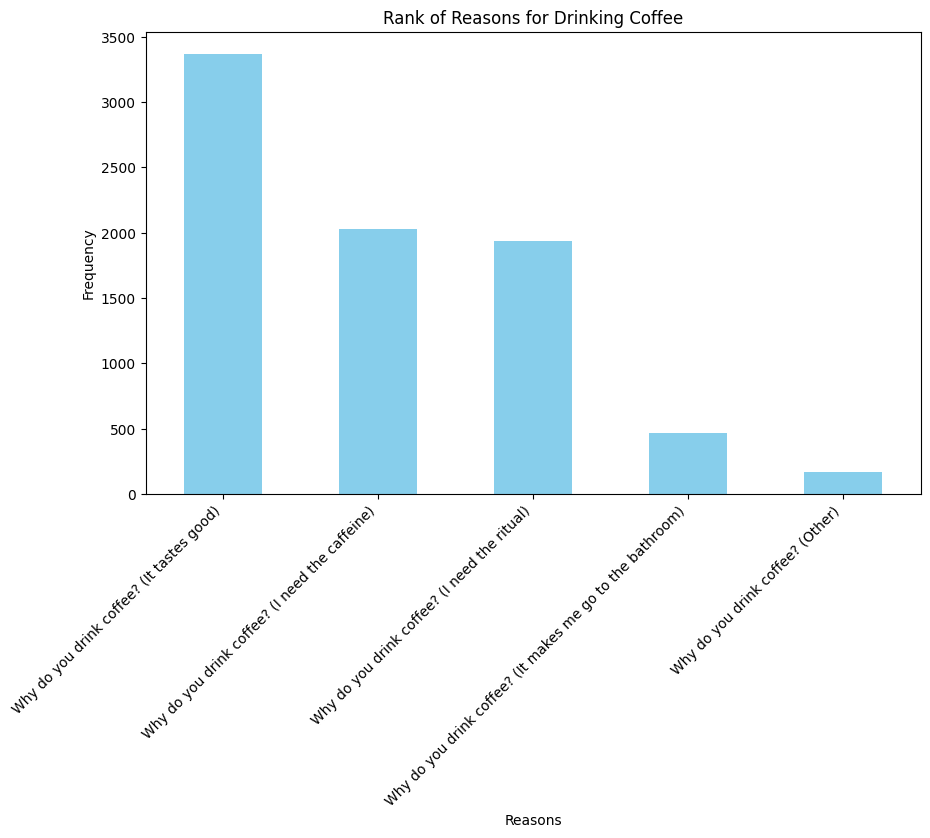

In [117]:
ranked_reasons.plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title("Rank of Reasons for Drinking Coffee")
plt.ylabel("Frequency")
plt.xlabel("Reasons")
plt.xticks(rotation=45, ha='right')
plt.show()

## Other reason for drinking coffee 

In [119]:
feature_looking(df, 'Other reason for drinking coffee')

column name    :  Other reason for drinking coffee
--------------------------------
per_of_nulls   :  % 95.86
num_of_nulls   :  3894
num_of_uniques :  164
shape_of_df    :  (4062, 51)
--------------------------------
Other reason for drinking coffee
NaN                                                                                                                                                                                                   3894
Social                                                                                                                                                                                                   3
Stimulant self medication                                                                                                                                                                                2
I don't generally drink coffee                                                                                                               

## Do you like the taste of coffee?

In [121]:
feature_looking(df, 'Do you like the taste of coffee?')

column name    :  Do you like the taste of coffee?
--------------------------------
per_of_nulls   :  % 11.87
num_of_nulls   :  482
num_of_uniques :  3
shape_of_df    :  (4062, 51)
--------------------------------
Do you like the taste of coffee?
Yes    3476
NaN     482
No      104
Name: count, dtype: int64


In [122]:
df[df['Do you like the taste of coffee?'].isnull() & df['Why do you drink coffee? (It tastes good)'] == 1][['Do you like the taste of coffee?', 'Why do you drink coffee? (It tastes good)']]

,Do you like the taste of coffee?,Why do you drink coffee? (It tastes good)
554,NaN,1.0
600,NaN,1.0
620,NaN,1.0
1194,NaN,1.0
1653,NaN,1.0
2234,NaN,1.0
2441,NaN,1.0
3569,NaN,1.0


In [123]:
df[df['Do you like the taste of coffee?'].isnull() & (df['Why do you drink coffee? (It tastes good)'] == 0)][['Do you like the taste of coffee?', 'Why do you drink coffee? (It tastes good)']]

,Do you like the taste of coffee?,Why do you drink coffee? (It tastes good)
152,NaN,0.0
1504,NaN,0.0
2828,NaN,0.0


In [124]:
df[df['Do you like the taste of coffee?'].isna() & (df['Why do you drink coffee? (It tastes good)'] == 1.0)]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
554,2422,Al6PLz,25-34 years old,2,At a cafe,"On the go, At home",Coffee brewing machine (e.g. Mr. Coffee),Scale,Independent,National chain (e.g. Starbucks/Dunkin),...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,93722,Yes
600,2155,OABRPK,35-44 years old,3,At home,NaN,Pod/capsule machine (e.g. Keurig/Nespresso),French Press,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,11221,No
620,1330,7d9r0P,35-44 years old,2,On the go,"At a cafe, At home",Pour over,Espresso Machine,Chain,Local cafe,...,Bachelor's degree,Hispanic/Latino,NaN,Unemployed,NaN,No affiliation,True,Subscription - Medium,60647,NaN
1194,1787,LdM2E1,45-54 years old,2,At home,NaN,Pour over,French Press,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,2919,Yes
1653,3221,6dr82B,25-34 years old,NaN,At home,At a cafe,Pour over,French Press,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,60546,Yes
2234,3752,WADM8v,25-34 years old,2,At home,"At the office, At a cafe",Pour over,Scale,Specialty,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,10474,No
2441,3420,5dE9EP,>65 years old,4,At home,NaN,Bean-to-cup machine,Milk Frother,Independent,NaN,...,Bachelor's degree,White/Caucasian,NaN,Retired,NaN,Independent,True,Subscription - Medium,10459,Yes
3569,2024,xdNqzG,25-34 years old,2,At the office,NaN,NaN,Coffee Grinder,Independent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,60632,NaN


In [125]:
df[df['Do you like the taste of coffee?'].isna() & (df['Why do you drink coffee? (It tastes good)'] == 0.0)]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts
152,950,EPb7N2,35-44 years old,1,At home,NaN,Pour over,Grinder,Local,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Light,2886,Yes
1504,2709,VZ90e6,18-24 years old,Less than 1,On the go,NaN,NaN,Espresso Machine,Local,Drive-thru,...,NaN,NaN,NaN,NaN,NaN,NaN,True,Subscription - Medium,2904,Yes
2828,2212,ylqLXd,45-54 years old,1,At home,NaN,Espresso,French Press,Independent,NaN,...,Bachelor's degree,White/Caucasian,NaN,Employed part-time,2,Republican,True,Subscription - Medium,11697,No


In [126]:
df['Do you like the taste of coffee?'] = df['Do you like the taste of coffee?'].fillna(
    df['Why do you drink coffee? (It tastes good)'].map({1.0: 'Yes', 0.0: 'No'})
)

In [127]:
feature_looking(df, 'Do you like the taste of coffee?')

column name    :  Do you like the taste of coffee?
--------------------------------
per_of_nulls   :  % 11.6
num_of_nulls   :  471
num_of_uniques :  3
shape_of_df    :  (4062, 51)
--------------------------------
Do you like the taste of coffee?
Yes    3484
NaN     471
No      107
Name: count, dtype: int64


## Do you know where your coffee comes from?

In [129]:
feature_looking(df, 'Do you know where your coffee comes from?')

column name    :  Do you know where your coffee comes from?
--------------------------------
per_of_nulls   :  % 11.96
num_of_nulls   :  486
num_of_uniques :  3
shape_of_df    :  (4062, 51)
--------------------------------
Do you know where your coffee comes from?
Yes    2733
No      843
NaN     486
Name: count, dtype: int64


## What is the most you've ever paid for a cup of coffee?

In [131]:
feature_looking(df, 'What is the most you\'ve ever paid for a cup of coffee?')

column name    :  What is the most you've ever paid for a cup of coffee?
--------------------------------
per_of_nulls   :  % 12.75
num_of_nulls   :  518
num_of_uniques :  9
shape_of_df    :  (4062, 51)
--------------------------------
What is the most you've ever paid for a cup of coffee?
$6-$8            1099
$8-$10           1005
$10-$15           618
NaN               518
$4-$6             453
$15-$20           185
More than $20     129
$2-$4              43
Less than $2       12
Name: count, dtype: int64


## What is the most you'd ever be willing to pay for a cup of coffee?

In [133]:
feature_looking(df, 'What is the most you\'d ever be willing to pay for a cup of coffee?')

column name    :  What is the most you'd ever be willing to pay for a cup of coffee?
--------------------------------
per_of_nulls   :  % 13.17
num_of_nulls   :  535
num_of_uniques :  9
shape_of_df    :  (4062, 51)
--------------------------------
What is the most you'd ever be willing to pay for a cup of coffee?
$8-$10           884
$10-$15          653
$6-$8            642
More than $20    581
NaN              535
$4-$6            334
$15-$20          329
$2-$4             85
Less than $2      19
Name: count, dtype: int64


## Do you feel like you’re getting good value for your money when you buy coffee at a cafe?

In [135]:
feature_looking(df, 'Do you feel like you’re getting good value for your money when you buy coffee at a cafe?')

column name    :  Do you feel like you’re getting good value for your money when you buy coffee at a cafe?
--------------------------------
per_of_nulls   :  % 13.42
num_of_nulls   :  545
num_of_uniques :  3
shape_of_df    :  (4062, 51)
--------------------------------
Do you feel like you’re getting good value for your money when you buy coffee at a cafe?
Yes    2057
No     1460
NaN     545
Name: count, dtype: int64


## Approximately how much have you spent on coffee equipment in the past 5 years?

In [137]:
feature_looking(df, 'Approximately how much have you spent on coffee equipment in the past 5 years?')

column name    :  Approximately how much have you spent on coffee equipment in the past 5 years?
--------------------------------
per_of_nulls   :  % 13.27
num_of_nulls   :  539
num_of_uniques :  8
shape_of_df    :  (4062, 51)
--------------------------------
Approximately how much have you spent on coffee equipment in the past 5 years?
More than $1,000    783
$100-$300           755
$500-$1000          644
$300-$500           599
NaN                 539
$50-$100            310
Less than $20       243
$20-$50             189
Name: count, dtype: int64


## Do you feel like you’re getting good value for your money with regards to your coffee equipment?

In [139]:
feature_looking(df, 'Do you feel like you’re getting good value for your money with regards to your coffee equipment?')

column name    :  Do you feel like you’re getting good value for your money with regards to your coffee equipment?
--------------------------------
per_of_nulls   :  % 13.56
num_of_nulls   :  551
num_of_uniques :  3
shape_of_df    :  (4062, 51)
--------------------------------
Do you feel like you’re getting good value for your money with regards to your coffee equipment?
Yes    3335
NaN     551
No      176
Name: count, dtype: int64


## Lastly, how would you rate your own coffee expertise?

In [141]:
feature_looking(df, 'Lastly, how would you rate your own coffee expertise?')

column name    :  Lastly, how would you rate your own coffee expertise?
--------------------------------
per_of_nulls   :  % 2.56
num_of_nulls   :  104
num_of_uniques :  11
shape_of_df    :  (4062, 51)
--------------------------------
Lastly, how would you rate your own coffee expertise?
7.0     947
6.0     856
5.0     583
8.0     490
4.0     358
3.0     273
2.0     168
1.0     155
NaN     104
9.0      88
10.0     40
Name: count, dtype: int64


## Gender

In [143]:
feature_looking(df, 'Gender')

column name    :  Gender
--------------------------------
per_of_nulls   :  % 12.85
num_of_nulls   :  522
num_of_uniques :  6
shape_of_df    :  (4062, 51)
--------------------------------
Gender
Male                      2537
Female                     856
NaN                        522
Non-binary                 103
Prefer not to say           34
Other (please specify)      10
Name: count, dtype: int64


## Gender (please specify)

In [145]:
feature_looking(df, 'Gender (please specify)')

column name    :  Gender (please specify)
--------------------------------
per_of_nulls   :  % 99.7
num_of_nulls   :  4050
num_of_uniques :  12
shape_of_df    :  (4062, 51)
--------------------------------
Gender (please specify)
NaN                             4050
Transgender Female                 2
Male + female                      1
I'm offended by the question       1
Male/Female couple                 1
bi-gender                          1
Transmasc Genderqueer              1
Gender queer                       1
working on this one                1
Cis                                1
Nonbinary woman                    1
no                                 1
Name: count, dtype: int64


In [146]:
df[df['Gender']=='Other (please specify)'][['Gender', 'Gender (please specify)']]

,Gender,Gender (please specify)
321,Other (please specify),Male + female
1014,Other (please specify),Transgender Female
2215,Other (please specify),bi-gender
2812,Other (please specify),Transmasc Genderqueer
2881,Other (please specify),Gender queer
3212,Other (please specify),working on this one
3456,Other (please specify),Transgender Female
3506,Other (please specify),Cis
3538,Other (please specify),Nonbinary woman
3791,Other (please specify),no


## Education Level

In [148]:
feature_looking(df, 'Education Level')

column name    :  Education Level
--------------------------------
per_of_nulls   :  % 14.94
num_of_nulls   :  607
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
Education Level
Bachelor's degree                     1766
Master's degree                        744
NaN                                    607
Some college or associate's degree     463
Doctorate or professional degree       341
High school graduate                   119
Less than high school                   22
Name: count, dtype: int64


## Ethnicity/Race

In [150]:
feature_looking(df,'Ethnicity/Race')

column name    :  Ethnicity/Race
--------------------------------
per_of_nulls   :  % 15.44
num_of_nulls   :  627
num_of_uniques :  7
shape_of_df    :  (4062, 51)
--------------------------------
Ethnicity/Race
White/Caucasian                  2640
NaN                               627
Asian/Pacific Islander            412
Hispanic/Latino                   218
Other (please specify)            112
Black/African American             39
Native American/Alaska Native      14
Name: count, dtype: int64


## Ethnicity/Race (please specify)

In [152]:
feature_looking(df, 'Ethnicity/Race (please specify)')

column name    :  Ethnicity/Race (please specify)
--------------------------------
per_of_nulls   :  % 97.39
num_of_nulls   :  3956
num_of_uniques :  83
shape_of_df    :  (4062, 51)
--------------------------------
Ethnicity/Race (please specify)
NaN                        3956
Mixed                         7
Indian                        5
Middle Eastern                3
White/Asian                   3
                           ... 
Multi-Ethnic                  1
Egyptian                      1
White/Hispanic                1
Mixed: Filipino & White       1
South Asia/Pakistan           1
Name: count, Length: 83, dtype: int64


In [153]:
df[df['Ethnicity/Race'].isnull() & df['Ethnicity/Race (please specify)'].notnull()]

,F1,Submission ID,What is your age?,How many cups of coffee do you typically drink per day?,Where do you typically drink coffee? Choice_nr_1,Where do you typically drink coffee? Choice_nr_2,How do you brew coffee at home?1,coffee_accessories,coffee_shop_preference,"On the go, where do you typically purchase coffee?1",...,Education Level,Ethnicity/Race,Ethnicity/Race (please specify),Employment Status,Number of Children,Political Affiliation,coffee_subscription,Subscription - majority roast,ZipCodes,discounts


In [154]:
df[(df['Ethnicity/Race'] == 'Other (please specify)') & df['Ethnicity/Race (please specify)'].notnull()][['Ethnicity/Race', 'Ethnicity/Race (please specify)']]

,Ethnicity/Race,Ethnicity/Race (please specify)
64,Other (please specify),Africa American and European
82,Other (please specify),White + Asian
118,Other (please specify),Asian/White
142,Other (please specify),Caucasion and Latino
265,Other (please specify),50|50 White/Asian
...,...,...
3791,Other (please specify),No
3811,Other (please specify),Hispanic/Asian
3970,Other (please specify),White/Asian
3971,Other (please specify),South Asia/Pakistan


In [155]:
df['Ethnicity/Race'].unique()

array(['White/Caucasian', nan, 'Asian/Pacific Islander',
       'Hispanic/Latino', 'Other (please specify)',
       'Black/African American', 'Native American/Alaska Native'],
      dtype=object)

In [156]:
df['Ethnicity/Race (please specify)'].unique()

array([nan, 'Africa American and European', 'White + Asian',
       'Asian/White', 'Caucasion and Latino', '50|50 White/Asian',
       'Indian', 'Jewish', 'White/South Asian',
       'White, Black, Native American', 'American', 'Mixed', 'Mix',
       'Multiracial', 'Mixed - Asian and Black', 'Middle eastern', 'Mutt',
       'Korean', 'Prefer not to say', 'Mix of white/asian', 'White/Asian',
       'Black and asian', 'Asian White Mix', 'human', 'Middle Eastern',
       'White and latina', 'Bi-racial', 'Asian/white biracial',
       'Mexican and Japanese', 'Mixed: Filipino & White',
       'White/Hispanic', 'Egyptian', 'Multi-Ethnic', 'white/asian',
       'Asian Indian', 'Biracial, Black and White', 'Asian, Caucasian',
       'white/chinese', 'Middle Eastern/Arab', 'Mixed race',
       'Asian and white', 'Mixed Asian Caucasian', 'AR-15',
       'mixed asian/caucasian', 'White Latina',
       'South Asian (Indian subcontinent)', 'Japanese Bolivian', 'mixed',
       'No', 'White and Hispa

In [157]:
ethnicity_mapping = {
    r'(?i).*white.*asian.*|.*asian.*white.*|.*white.*&.*asian.*|.*50\|50.*|.*white.*asian.*|.*white/chinese.*': 'White/Caucasian',  # White/Caucasian & variations
    r'(?i).*biracial.*asian.*white.*|.*biracial.*(asian|white).*|.*asian.*white.*biracial.*|.*asian.*and.*white.*': 'White/Caucasian',  # Biracial combinations for White/Asian
    r'(?i).*white.*black.*': 'Black/African American',  # White/Black combinations
    r'(?i).*black.*asian.*': 'Black/African American',  # Black and Asian combinations
    r'(?i).*africa american and european.*|.*african.*american.*': 'Black/African American',  # African American combinations
    r'(?i).*latino.*|.*hispanic.*|.*white.*latino.*|.*white.*hispanic.*|.*white latina.*|.*White and latina.*': 'Hispanic/Latino',  # Latino/Hispanic variations
    r'(?i).*mexican.*': 'Hispanic/Latino',  # Mexican origin as Latino/Hispanic
    r'(?i).*asian.*hispanic.*': 'Hispanic/Latino',  # Asian/Hispanic combinations
    r'(?i).*middle.?eastern.*|.*arab.*|.*persian.*|.*turkish.*|.*kurdish.*': 'Other',  # Middle Eastern
    r'(?i).*egyptian.*': 'Other',  # Egyptian (often grouped under Middle Eastern)
    r'(?i).*prefer not to say.*|.*doesn\'t matter.*|.*no.*': 'Other',  # People who chose not to disclose or ambiguous responses
    r'(?i).*south asian.*|.*indian.*|.*pakistani.*|.*south asia/pakistan.*': 'Other',  # South Asian variations
    r'(?i).*native american.*|.*alaskan native.*': 'Native American/Alaska Native',  # Native American/Alaska Native
    r'(?i).*multiracial.*|.*mixed.*|.*multi-ethnic.*|.*mixed.*race.*|.*mix.*|.*huge mix.*|.*two races.*': 'Other',  # Multiracial/Mixed
    r'(?i).*caucasian.*': 'White/Caucasian',  # Caucasian related terms
    r'(?i).*jewish.*|.*ashkenazim.*': 'Other',  # Jewish identity
    r'(?i).*mutt.*|.*human.*|.*AR-15.*': 'Other',  # Miscellaneous terms like "Mutt", "Human"
    r'(?i).*bi-racial.*|.*bi-racial.*': 'Other',  # Bi-racial combinations
    r'(?i).*american.*': 'Other',  # General American (undefined)
    r'(?i).*white.*taiwanese.*': 'White/Caucasian',  # White & Taiwanese
    r'(?i).*white european & british romani.*': 'Other',  # White European and British Romani
    r'(?i).*japanese bolivian.*': 'Other',  # Japanese Bolivian mixed heritage
}


In [158]:
# Function to clean and map 'Ethnicity/Race (please specify)' values to 'Ethnicity/Race'
def map_ethnicity(value):
    if pd.isna(value):
        return np.nan
    value = value.strip()
    for pattern, replacement in ethnicity_mapping.items():
        if pd.Series(value).str.contains(pattern, regex=True).any():
            return replacement
    return 'Other (please specify)'  # Return 'Other' if no mapping is found

In [159]:
# Apply mapping function to fill 'Ethnicity/Race' column with standardized values
df['Ethnicity/Race'] = df.apply(
    lambda row: map_ethnicity(row['Ethnicity/Race (please specify)']) 
    if row['Ethnicity/Race'] == 'Other (please specify)' 
    else row['Ethnicity/Race'], axis=1
)

# Drop the 'Ethnicity/Race (please specify)' column if no longer needed
df.drop(columns=['Ethnicity/Race (please specify)'], inplace=True)

In [160]:
df['Ethnicity/Race'].unique()

array(['White/Caucasian', nan, 'Asian/Pacific Islander',
       'Hispanic/Latino', 'Black/African American',
       'Native American/Alaska Native', 'Other'], dtype=object)

In [161]:
feature_looking(df,'Ethnicity/Race')

column name    :  Ethnicity/Race
--------------------------------
per_of_nulls   :  % 15.61
num_of_nulls   :  634
num_of_uniques :  7
shape_of_df    :  (4062, 50)
--------------------------------
Ethnicity/Race
White/Caucasian                  2670
NaN                               634
Asian/Pacific Islander            412
Hispanic/Latino                   228
Other                              60
Black/African American             42
Native American/Alaska Native      16
Name: count, dtype: int64


* The values in the Ethnicity/race column are NaN and the values in the Ethnicity/race (please specify) column are also NaN, so the NaN values in the Ethnicity/race column could not be filled.
* However, the 'Other (please specify)' values in the Ethnicity/race column were filled by classifying the corresponding values in the Ethnicity/race (please specify) column and the Ethnicity/race (please specify) column has been dropped.

## Employment Status

In [164]:
feature_looking(df, 'Employment Status')

column name    :  Employment Status
--------------------------------
per_of_nulls   :  % 15.41
num_of_nulls   :  626
num_of_uniques :  7
shape_of_df    :  (4062, 50)
--------------------------------
Employment Status
Employed full-time    2719
NaN                    626
Student                223
Employed part-time     201
Unemployed             128
Retired                 87
Homemaker               78
Name: count, dtype: int64


## Number of Children

In [166]:
feature_looking(df, 'Number of Children')

column name    :  Number of Children
--------------------------------
per_of_nulls   :  % 78.78
num_of_nulls   :  3200
num_of_uniques :  5
shape_of_df    :  (4062, 50)
--------------------------------
Number of Children
NaN            3200
2               406
1               311
3                93
More than 3      52
Name: count, dtype: int64


## Political Affiliation

In [168]:
feature_looking(df, 'Political Affiliation')

column name    :  Political Affiliation
--------------------------------
per_of_nulls   :  % 18.64
num_of_nulls   :  757
num_of_uniques :  5
shape_of_df    :  (4062, 50)
--------------------------------
Political Affiliation
Democrat          1778
No affiliation     831
NaN                757
Independent        507
Republican         189
Name: count, dtype: int64


## coffee_subscription

In [170]:
feature_looking(df, 'coffee_subscription')

column name    :  coffee_subscription
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  2
shape_of_df    :  (4062, 50)
--------------------------------
coffee_subscription
True     3940
False     122
Name: count, dtype: int64


## Subscription - majority roast

In [172]:
feature_looking(df, 'Subscription - majority roast')

column name    :  Subscription - majority roast
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  14
shape_of_df    :  (4062, 50)
--------------------------------
Subscription - majority roast
Subscription - Light        1787
Subscription - Medium       1574
Subscription - Dark          422
Subscription - Nordic         78
Subscription -                75
Subscription - Blonde         73
Subscription - Italian        23
Subscription - French         21
Subscription - Mediumm         3
Subscription - Light           2
Subscription - Ligh  t         1
Subscription - Medium          1
Subscription -      Dark       1
Subscription -    Blonde       1
Name: count, dtype: int64


In [173]:
# Define function to clean values
def clean_roast(value):
    if pd.isna(value) or not isinstance(value, str):  # Handle NaN and non-string values
        return None
    
    # Define regex-based replacements
    replacements = {
        r'(?i)subscription -\s*ligh\s*t': 'Light',
        r'(?i)subscription -\s*medium+': 'Medium',
        r'(?i)subscription -\s*dark\s*': 'Dark',
        r'(?i)subscription -\s*nordic': 'Nordic',
        r'(?i)subscription -\s*blonde': 'Blonde',
        r'(?i)subscription -\s*italian': 'Italian',
        r'(?i)subscription -\s*french': 'French',
        r'(?i)subscription -\s*$': None  # Empty or malformed values -> Set to None
    }
    
    # Apply regex replacements
    for pattern, replacement in replacements.items():
        if re.match(pattern, value):
            return replacement
    
    return value  # Return original if no match

In [174]:
# Apply the function to the DataFrame
df["Subscription - majority roast"] = df["Subscription - majority roast"].apply(clean_roast)

In [175]:
feature_looking(df, 'Subscription - majority roast')

column name    :  Subscription - majority roast
--------------------------------
per_of_nulls   :  % 1.85
num_of_nulls   :  75
num_of_uniques :  8
shape_of_df    :  (4062, 50)
--------------------------------
Subscription - majority roast
Light      1790
Medium     1578
Dark        423
Nordic       78
None         75
Blonde       74
Italian      23
French       21
Name: count, dtype: int64


* Misspelled and inconsistent values were corrected using a predefined dictionary with regex patterns to ensure data consistency.

## ZipCodes

In [178]:
feature_looking(df, 'ZipCodes')

column name    :  ZipCodes
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  180
shape_of_df    :  (4062, 50)
--------------------------------
ZipCodes
10459    168
11208     43
11368     41
10474     36
10010     33
        ... 
2155      13
92154     13
95076     12
2301      11
2148      10
Name: count, Length: 180, dtype: int64


In [179]:
# Convert ZIP codes to integer (if error occur make them NaN)
df["ZipCodes"] = pd.to_numeric(df["ZipCodes"], errors="coerce")

df["State"] = df["ZipCodes"].apply(lambda x: get_state(x) if pd.notna(x) else "Unknown")

print("New column added!")

New column added!


In [180]:
feature_looking(df, 'State')

column name    :  State
--------------------------------
per_of_nulls   :  % 0.0
num_of_nulls   :  0
num_of_uniques :  18
shape_of_df    :  (4062, 51)
--------------------------------
State
New York         2345
California        724
Rhode Island      389
Texas             150
Alaska            114
Illinois           74
New Jersey         39
Massachusetts      34
Pennsylvania       20
Washington         20
Alabama            20
Connecticut        20
Georgia            19
Missouri           19
Utah               19
Michigan           19
Iowa               19
Florida            18
Name: count, dtype: int64


## discounts

In [182]:
feature_looking(df, 'discounts')

column name    :  discounts
--------------------------------
per_of_nulls   :  % 5.0
num_of_nulls   :  203
num_of_uniques :  3
shape_of_df    :  (4062, 51)
--------------------------------
discounts
Yes    1961
No     1898
NaN     203
Name: count, dtype: int64


In [183]:
threshold = 0.85  # 85% NaN threshold
df = df.loc[:, df.isna().mean() < threshold]

In [184]:
first_looking(df)

Shape:(4062, 47)
****************************************************************************************************
Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4062 entries, 0 to 4061
Data columns (total 47 columns):
 #   Column                                                                                            Non-Null Count  Dtype  
---  ------                                                                                            --------------  -----  
 0   F1                                                                                                4062 non-null   int64  
 1   Submission ID                                                                                     4062 non-null   object 
 2   What is your age?                                                                                 4031 non-null   object 
 3   How many cups of coffee do you typically drink per day?                                           3969 non-null   object 
 4   W

In [185]:
df = df.fillna("UNKNOWN")

In [186]:
df.to_excel('coffee_survey_sallys_brew_2024_cleaned.xlsx', index=False)

# Sales.py Excel File
### Created State Column by Zip Codes

In [17]:
folder_path = "C:/Users/Ahmet/Desktop/Trainee/data"
file_name = "sales_py.xlsx" 

file_path = os.path.join(folder_path, file_name)

df_sales = pd.read_excel(file_path)

df_sales.head()

,zip,Sales (in USD),Year
0,11354,185591.475000,2024
1,10583,115220.757600,2024
2,60120,2165.544225,2024
3,98374,963.335100,2024
4,75087,1124.603025,2024


In [19]:
first_looking(df_sales)

Shape:(1384, 3)
****************************************************************************************************
Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384 entries, 0 to 1383
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   zip             1384 non-null   int64  
 1   Sales (in USD)  1384 non-null   float64
 2   Year            1384 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 32.6 KB
None
****************************************************************************************************
Number of Uniques:
zip               1384
Sales (in USD)    1324
Year                 1
dtype: int64
****************************************************************************************************
Missing Values:
Empty DataFrame
Columns: [Missing_Number, Missing_Percent]
Index: []
****************************************************************************************************


In [25]:
# Convert ZIP codes to integer (if error occur make them NaN)
df_sales["zip"] = pd.to_numeric(df_sales["zip"], errors="coerce")

df_sales["State"] = df_sales["zip"].apply(lambda x: get_state(x) if pd.notna(x) else "Unknown")

print("New column added!")
print(df_sales.head())

New column added!
     zip  Sales (in USD)  Year       State
0  11354   185591.475000  2024    New York
1  10583   115220.757600  2024    New York
2  60120     2165.544225  2024    Illinois
3  98374      963.335100  2024  Washington
4  75087     1124.603025  2024       Texas


In [23]:
df_sales.to_excel("updated_sales_py.xlsx", index=False)